Sesi 6 - Image Matching

- [] Feature Descriptor
- [] Feature Matching

- SIFT
- AKAZE
- ORB -> FAST + BRIEF

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [5]:
img = cv2.imread('object.jpg')
# print(img)
# gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

DATA_PATH = 'sushiimg/'
data = []

for img_path in os.listdir(DATA_PATH):
    img_path = DATA_PATH + img_path
    img_data = cv2.imread(img_path)
    data.append(img_data)


In [14]:
# Preprocess image -> object
target_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # output image
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.medianBlur(gray, 3)
gray = cv2.equalizeHist(gray)

In [7]:
# initialize algorithm (sift, akaze, orb)
sift = cv2.SIFT_create()
akaze = cv2.AKAZE_create()
orb = cv2.ORB_create()

In [8]:
# detect keypoints and descriptors
# -> return (keypoints, descriptors)

# sift
target_kp, target_des = sift.detectAndCompute(gray, None)

# akaze
# target_kp_akaze, target_des_akaze = akaze.detectAndCompute(gray, None)

# orb
# target_kp_orb, target_des_orb = orb.detectAndCompute(gray, None)

# convert to float32 supaya bisa dibaca
# sama algorithm selanjutnya
target_des = np.float32(target_des)

In [9]:
# Intialize match coutner -> track best matches, yang jelek false match kita buang
best_match = 0
best_match_data = None

In [15]:
# loop ke data images
for idx, img in enumerate(data):
    img_view = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.medianBlur(gray, 3)
    gray = cv2.equalizeHist(gray)

    # keypoints & descriptor
    img_kp, img_des = sift.detectAndCompute(gray, None)
    # img_kp, img_des = akaze.detectAndCompute(gray, None)
    # img_kp, img_des = orb.detectAndCompute(gray, None)

    # matching features sama target 
    # -> FLANN(index, search params)
    # SIFT & AKAZE
    index_params = dict(algorithm=1, trees=5)

    # ORB
    # index_params = dict(algorithm=6, table_number=12, key_size=20, multi_probe_level=2)

    search_params = dict(checks=50)

    # initialize flann algorithm
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    matches = flann.knnMatch(target_des, img_des, k=2)

    # intialize mask to keep track best matches
    matchesmask = [[0, 0] for _ in range(0, len(matches))]
    # [[1, 0],[0,0]]

    current_matches = 0

    # Lowe's ratio test -> filter good matches
    # First best matches compare with second best matches
    # ratio > threshold -> poor match
    # ratio < threshold -> best match
    for i, (fm, sm) in enumerate(matches):
        if fm.distance < 0.5 * sm.distance:
            matchesmask[i] = [1, 0] # mark as valid match
            current_matches += 1

    if current_matches > best_match:
        best_match = current_matches
        best_match_data = {
            'image_data': img_view,
            'keypoints': img_kp,
            'descriptors': img_des,
            'matches': matches,
            'matches_mask': matchesmask
        }

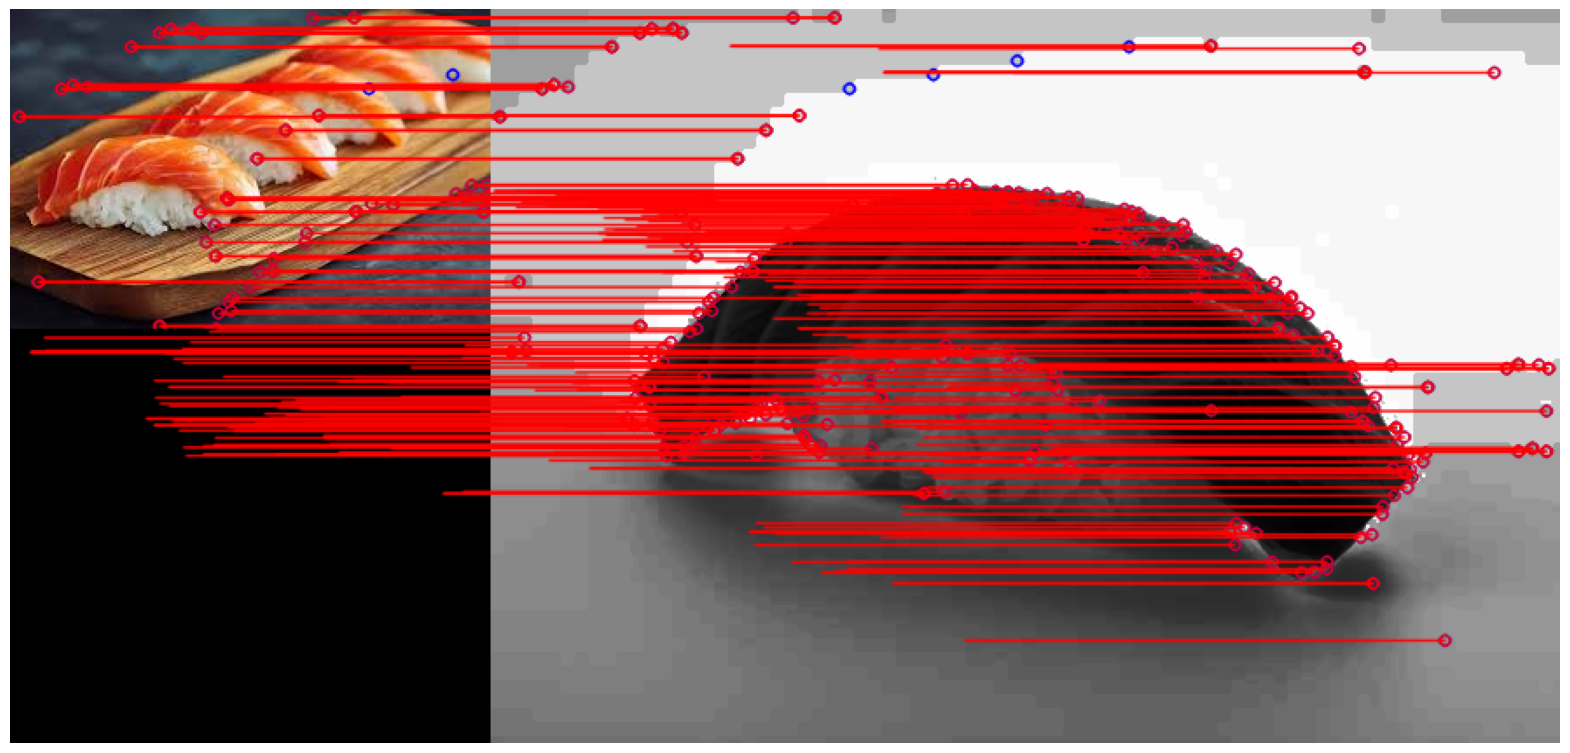

In [16]:
# visualize matching
result = cv2.drawMatchesKnn(
    target_img, # target img
    target_kp, # target keypoints
    best_match_data['image_data'], # image yang match
    best_match_data['keypoints'], # keypoints yang match
    best_match_data['matches'], # points yang match
    None, 
    matchesMask=best_match_data['matches_mask'], 
    matchColor=[255, 0, 0], # color for matching points
    singlePointColor=[0, 0, 255], # color for non-matching
)

plt.figure(figsize=(20, 10))
plt.imshow(result)
plt.axis('off')
plt.show()